# RIM Experiment Analysis

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rim_teleop.data import ExperimentRegistry, load_streams

DATA_DIR = "/home/athena/csirois/data/franka/rim"

registry = ExperimentRegistry(DATA_DIR)

# --- Select run ---
run_damping = registry.get("run_20260522_154437")
run_no_damping = registry.get("run_20260522_155110")
run_test2 = registry.get("run_20260522_161725")

print(f"Run with damping: {run_damping.name}  ({run_damping.created_at})")
print(f"Run without damping: {run_no_damping.name}  ({run_no_damping.created_at})")

Run with damping: run_20260522_154437  (2026-05-22 15:44:37.877569)
Run without damping: run_20260522_155110  (2026-05-22 15:51:10.653342)


In [22]:
streams_damping = load_streams(run_damping)
streams_no_damping = load_streams(run_no_damping)
streams_test2 = load_streams(run_test2)

# Normalise all timestamps to a shared t=0
t0_damping = min(df["ts"].min() for df in streams_damping.values())
for df in streams_damping.values():
    df["t"] = df["ts"] - t0_damping

t0_no_damping = min(df["ts"].min() for df in streams_no_damping.values())
for df in streams_no_damping.values():
    df["t"] = df["ts"] - t0_no_damping

t0_test2 = min(df["ts"].min() for df in streams_test2.values())
for df in streams_test2.values():
    df["t"] = df["ts"] - t0_test2

T_MAX_DAMPING = max(df["t"].max() for df in streams_damping.values())
T_MAX_NO_DAMPING = max(df["t"].max() for df in streams_no_damping.values())
T_MAX_TEST2 = max(df["t"].max() for df in streams_test2.values())
print(f"\nTotal duration (damping): {T_MAX_DAMPING:.1f} s")
print(f"Total duration (no damping): {T_MAX_NO_DAMPING:.1f} s")
print(f"Total duration (test2): {T_MAX_TEST2:.1f} s")


Total duration (damping): 82.1 s
Total duration (no damping): 45.8 s
Total duration (test2): 228.7 s


---
## Overview — full recording

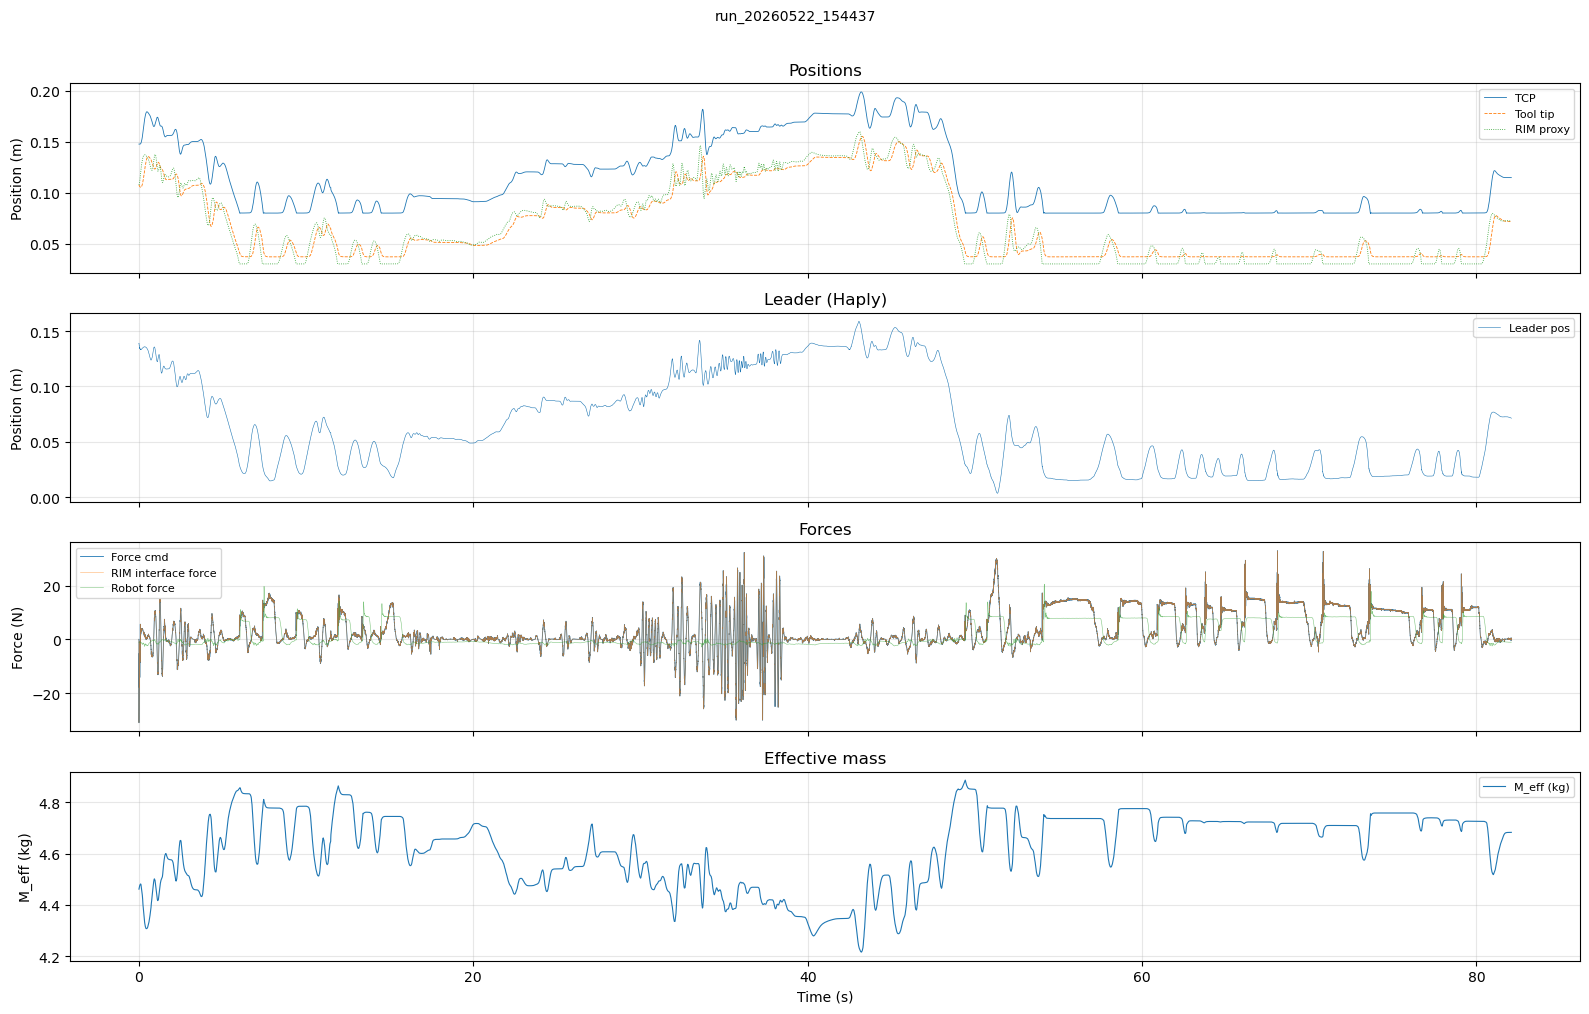

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# — Positions
ax = axes[0]
if "tracking" in streams_damping:
    tr = streams_damping["tracking"]
    ax.plot(tr["t"], tr["tcp"],      lw=0.6, label="TCP")
    ax.plot(tr["t"], tr["tool_tip"], lw=0.6, ls="--", label="Tool tip")
    ax.plot(tr["t"], tr["rim"],      lw=0.6, ls=":",  label="RIM proxy")
ax.set(ylabel="Position (m)", title="Positions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Haptic leader position
ax = axes[1]
if "haptic" in streams_damping:
    hap = streams_damping["haptic"]
    ax.plot(hap["t"], hap["leader_pos"], lw=0.4, label="Leader pos")
ax.set(ylabel="Position (m)", title="Leader (Haply)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Forces
ax = axes[2]
if "haptic" in streams_damping:
    ax.plot(hap["t"], hap["force_cmd"],          lw=0.6, label="Force cmd")
    if "rim_interface_force" in hap.columns:
        ax.plot(hap["t"], hap["rim_interface_force"], lw=0.4, alpha=0.6, label="RIM interface force")
    if "robot_force" in hap.columns:
        ax.plot(hap["t"], hap["robot_force"],         lw=0.4, alpha=0.6, label="Robot force")
ax.set(ylabel="Force (N)", title="Forces")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — RIM model
ax = axes[3]
if "rim_model" in streams_damping:
    rm = streams_damping["rim_model"]
    ax.plot(rm["t"], rm["M_eff"], lw=0.8, label="M_eff (kg)")
ax.set(xlabel="Time (s)", ylabel="M_eff (kg)", title="Effective mass")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(run_damping.name, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

---
## Time range selection

Set `T_START` and `T_END` (seconds, normalised) to zoom into a region of interest.
Set either to `None` to keep the full extent.

In [24]:
T_START = 116   # e.g. 10.0
T_END   = 119   # e.g. 25.0

def clip(df: pd.DataFrame, t_start=T_START, t_end=T_END) -> pd.DataFrame:
    """Return rows within [t_start, t_end] (inclusive, None = unbounded)."""
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= df["t"] >= t_start
    if t_end is not None:
        mask &= df["t"] <= t_end
    return df[mask]

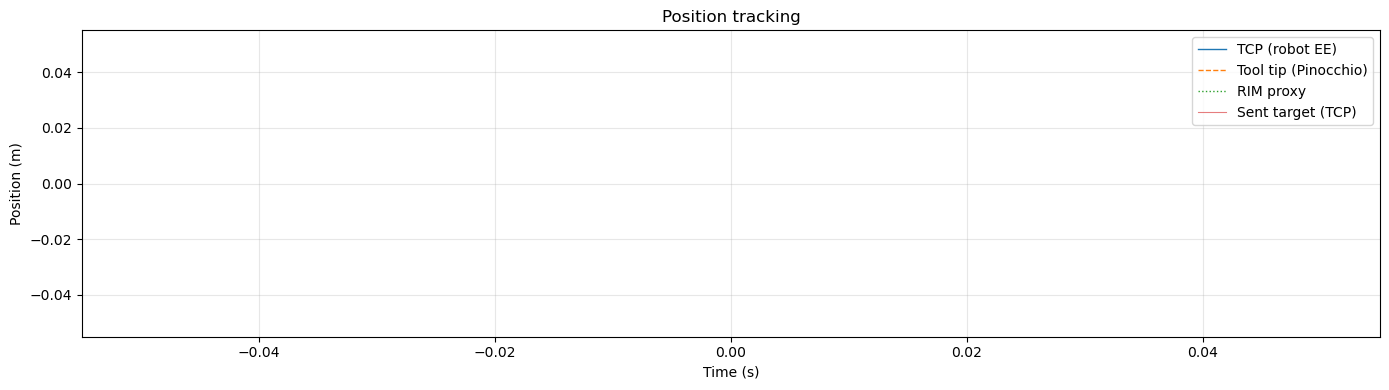

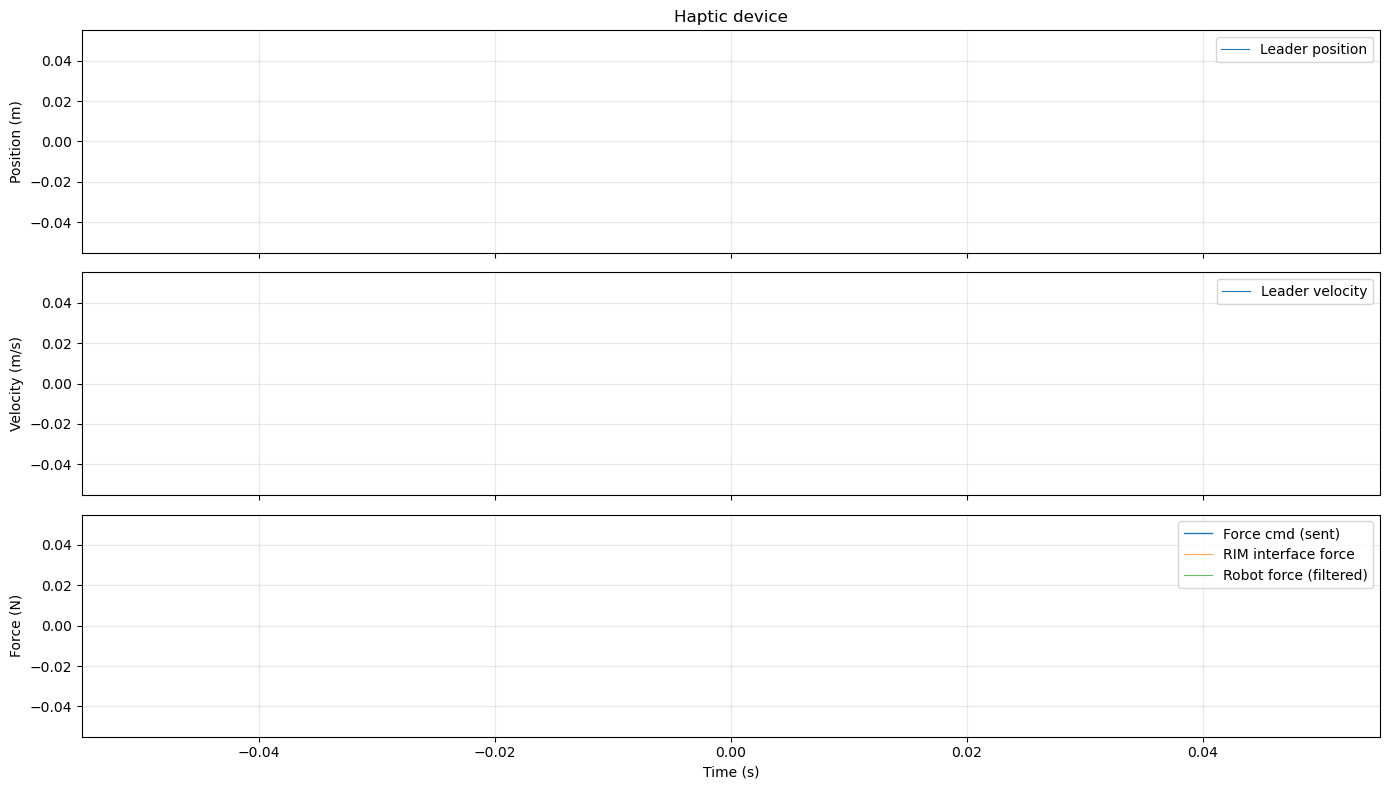

In [25]:
if "tracking" in streams_damping:
    tr = clip(streams_damping["tracking"])
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(tr["t"], tr["tcp"],      lw=1.0, label="TCP (robot EE)")
    ax.plot(tr["t"], tr["tool_tip"], lw=1.0, ls="--", label="Tool tip (Pinocchio)")
    ax.plot(tr["t"], tr["rim"],      lw=1.0, ls=":",  label="RIM proxy")
    ax.plot(tr["t"], tr["target"],   lw=0.8, alpha=0.6, label="Sent target (TCP)")
    ax.set(xlabel="Time (s)", ylabel="Position (m)", title="Position tracking")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


if "haptic" in streams_damping:
    hap = clip(streams_damping["haptic"])
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(hap["t"], hap["leader_pos"], lw=0.8, label="Leader position")
    axes[0].set(ylabel="Position (m)", title="Haptic device")
    axes[0].legend()

    axes[1].plot(hap["t"], hap["leader_vel"], lw=0.8, label="Leader velocity")
    axes[1].set(ylabel="Velocity (m/s)")
    axes[1].legend()

    axes[2].plot(hap["t"], hap["force_cmd"],          lw=1.0, label="Force cmd (sent)")
    if "rim_interface_force" in hap.columns:
        axes[2].plot(hap["t"], hap["rim_interface_force"], lw=0.8, alpha=0.7, label="RIM interface force")
    if "robot_force" in hap.columns:
        axes[2].plot(hap["t"], hap["robot_force"],         lw=0.8, alpha=0.7, label="Robot force (filtered)")
    axes[2].set(xlabel="Time (s)", ylabel="Force (N)")
    axes[2].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Contact Analysis

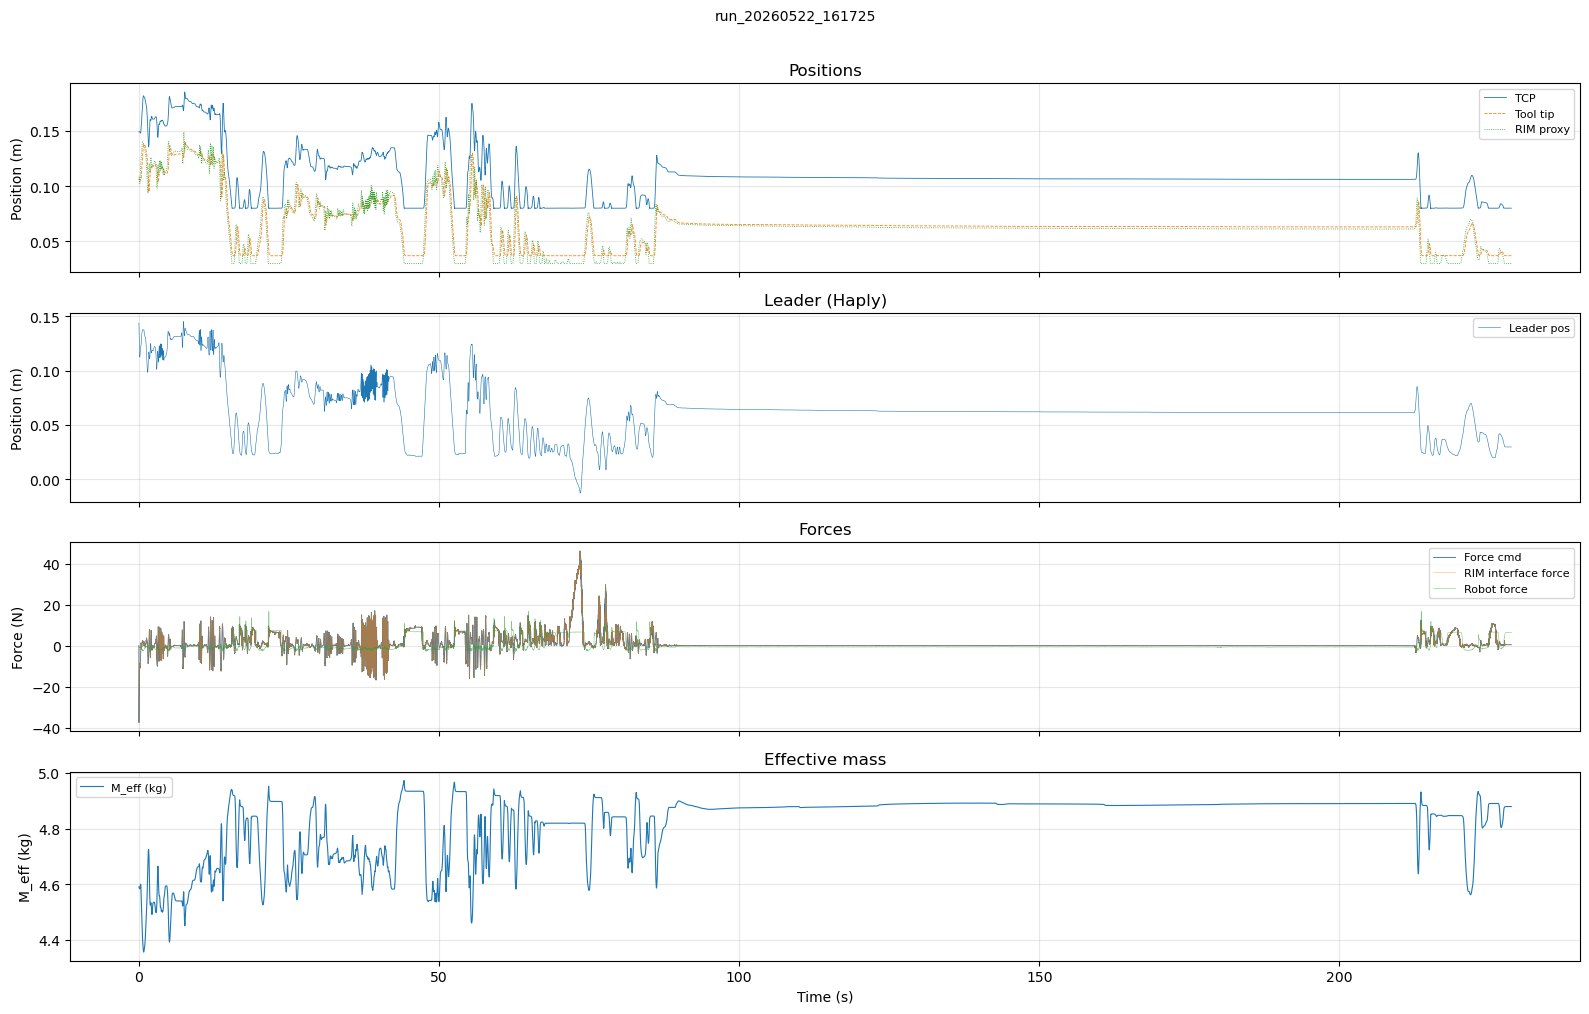

In [32]:
data_stream = streams_test2
run = run_test2

T_START = 63   # e.g. 10.0
T_END   = 65   # e.g. 25.0

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
# — Positions
ax = axes[0]
if "tracking" in data_stream:
    tr = data_stream["tracking"]
    ax.plot(tr["t"], tr["tcp"],      lw=0.6, label="TCP")
    ax.plot(tr["t"], tr["tool_tip"], lw=0.6, ls="--", label="Tool tip")
    ax.plot(tr["t"], tr["rim"],      lw=0.6, ls=":",  label="RIM proxy")
ax.set(ylabel="Position (m)", title="Positions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Haptic leader position
ax = axes[1]
if "haptic" in data_stream:
    hap = data_stream["haptic"]
    ax.plot(hap["t"], hap["leader_pos"], lw=0.4, label="Leader pos")
ax.set(ylabel="Position (m)", title="Leader (Haply)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Forces
ax = axes[2]
if "haptic" in data_stream:
    ax.plot(hap["t"], hap["force_cmd"],          lw=0.6, label="Force cmd")
    if "rim_interface_force" in hap.columns:
        ax.plot(hap["t"], hap["rim_interface_force"], lw=0.4, alpha=0.6, label="RIM interface force")
    if "robot_force" in hap.columns:
        ax.plot(hap["t"], hap["robot_force"],         lw=0.4, alpha=0.6, label="Robot force")
ax.set(ylabel="Force (N)", title="Forces")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — RIM model
ax = axes[3]
if "rim_model" in data_stream:
    rm = data_stream["rim_model"]
    ax.plot(rm["t"], rm["M_eff"], lw=0.8, label="M_eff (kg)")
ax.set(xlabel="Time (s)", ylabel="M_eff (kg)", title="Effective mass")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(run.name, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

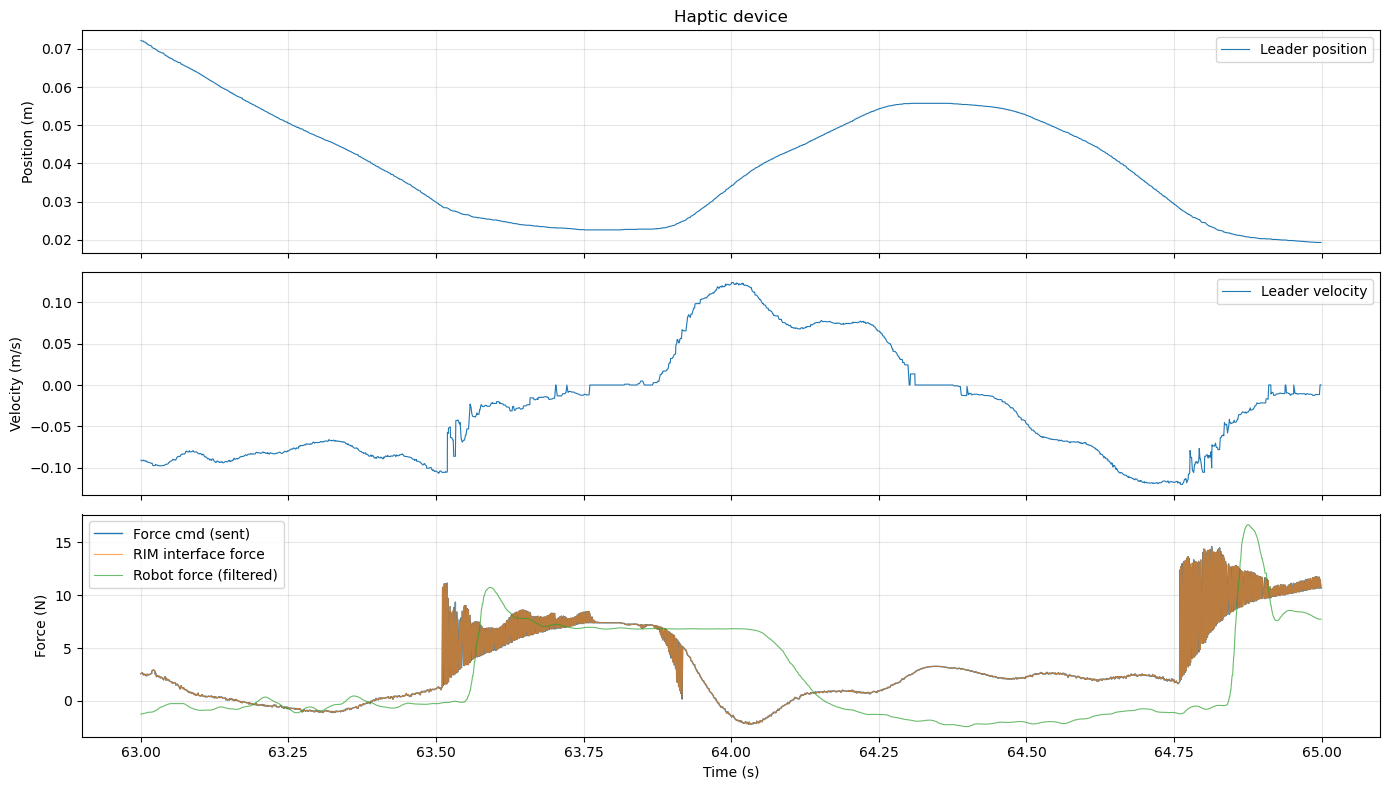

In [33]:
hap_df = clip(data_stream["haptic"], T_START, T_END)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(hap_df["t"], hap_df["leader_pos"], lw=0.8, label="Leader position")
axes[0].set(ylabel="Position (m)", title="Haptic device")
axes[0].legend()

axes[1].plot(hap_df["t"], hap_df["leader_vel"], lw=0.8, label="Leader velocity")
axes[1].set(ylabel="Velocity (m/s)")
axes[1].legend()

axes[2].plot(hap_df["t"], hap_df["force_cmd"],          lw=1.0, label="Force cmd (sent)")
if "rim_interface_force" in hap_df.columns:
    axes[2].plot(hap_df["t"], hap_df["rim_interface_force"], lw=0.8, alpha=0.7, label="RIM interface force")
if "robot_force" in hap_df.columns:
    axes[2].plot(hap_df["t"], hap_df["robot_force"],         lw=0.8, alpha=0.7, label="Robot force (filtered)")
axes[2].set(xlabel="Time (s)", ylabel="Force (N)")
axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()